In [1]:
##import necessary libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
#import the OS environment variables
os.environ["OMP_NUM_THREADS"] = '1'

In [3]:
#import the dataset into a pandas dataframe

dataset = pd.read_csv("Copy of sku_data.csv")

In [4]:
# The info(),describe(),head() funtion gives us various infomation about the dataset

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2279 entries, 0 to 2278
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2279 non-null   int64  
 1   Unitprice        2279 non-null   float64
 2   Expire date      2279 non-null   int64  
 3   Outbound number  2279 non-null   int64  
 4   Total outbound   2279 non-null   float64
 5   Pal grossweight  2279 non-null   float64
 6   Pal height       2279 non-null   float64
 7   Units per pal    2279 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 142.6 KB


In [5]:
dataset.describe()

,ID,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
count,2279.000000,2279.000000,2279.000000,2279.000000,2279.000000,2279.000000,2279.000000,2279.000000
mean,1140.000000,4.269402,410.371654,235.976305,731.701053,192.939582,0.672798,755.563405
std,658.034953,14.449000,240.875419,700.230685,2146.029848,164.616813,0.552117,6278.437915
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,570.500000,0.000000,365.000000,0.000000,0.000000,60.000000,0.000000,32.000000
50%,1140.000000,1.293800,547.000000,1.000000,3.000000,167.680000,0.840000,108.000000
75%,1709.500000,4.545000,547.000000,45.000000,419.500000,277.560000,1.020000,384.000000
max,2279.000000,518.592000,734.000000,6325.000000,26411.000000,907.200000,2.160000,200000.000000


In [6]:
dataset.head()

,ID,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
0,1,0.058,547,9,2441.0,105.60,1.56,1920
1,2,0.954,547,0,0.0,207.68,1.00,384
2,3,2.385,547,12,23.0,165.78,1.02,108
3,4,5.100,547,0,0.0,221.04,1.05,72
4,5,0.000,547,0,0.0,0.00,0.00,0


In [7]:
dataset.tail()

,ID,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
2274,2275,0.0,0,0,0.0,2.70,0.0,10
2275,2276,0.0,0,1,1.0,9.58,0.0,1
2276,2277,0.0,0,0,0.0,38.36,0.0,4
2277,2278,0.0,0,1,1.0,25.11,0.0,3
2278,2279,0.0,547,76,1570.0,105.60,0.0,1920


In [8]:
# print a correlation matrix to check relationships between variables

corr_matrix = dataset.corr(numeric_only=True)

print(corr_matrix)

                       ID  Unitprice  Expire date  Outbound number  \
ID               1.000000  -0.027168    -0.187731         0.167441   
Unitprice       -0.027168   1.000000    -0.038071        -0.012483   
Expire date     -0.187731  -0.038071     1.000000         0.209473   
Outbound number  0.167441  -0.012483     0.209473         1.000000   
Total outbound   0.135309  -0.039907     0.160389         0.864548   
Pal grossweight  0.002274   0.192024     0.261866         0.113197   
Pal height      -0.230368   0.095484     0.254724         0.192916   
Units per pal    0.026172  -0.031315    -0.097641        -0.025278   

                 Total outbound  Pal grossweight  Pal height  Units per pal  
ID                     0.135309         0.002274   -0.230368       0.026172  
Unitprice             -0.039907         0.192024    0.095484      -0.031315  
Expire date            0.160389         0.261866    0.254724      -0.097641  
Outbound number        0.864548         0.113197    0.192

In [9]:
X = dataset

In [10]:
##we applied feature scaling on the dataset through the standization method
#we also import agglomerativeClusterng algorithm from scikit learn

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

Scaler = StandardScaler()
X_scaled = Scaler.fit_transform(X)


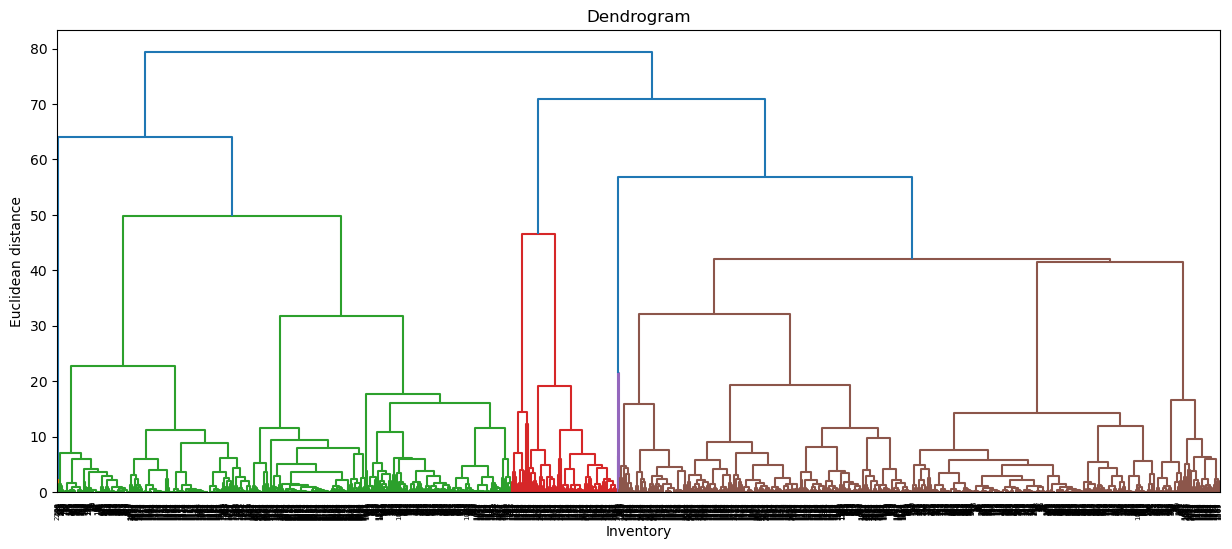

In [11]:
# visualize A dendogram showing the relationships between data in a hierarchical format

import scipy.cluster.hierarchy as sch
plt.figure(figsize=(15,6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Inventory')
plt.ylabel('Euclidean distance')
plt.show()

In [12]:
#Choose the optimal value of k from the dendogram
k = 6

hc = AgglomerativeClustering(n_clusters = k, metric = 'euclidean', linkage = 'ward')

In [13]:
y_hc = hc.fit_predict(X_scaled)

In [14]:
#Print the data points assigned to each cluster

print(f"\nClustering complete. Data points assigned to {k} clusters.")
print(f"Cluster labels shape: {y_hc.shape}")
print(f"Unique cluster counts:\n{pd.Series(y_hc).value_counts()}")


Clustering complete. Data points assigned to 6 clusters.
Cluster labels shape: (2279,)
Unique cluster counts:
1    1177
2     509
5     381
0     207
4       3
3       2
Name: count, dtype: int64


In [15]:
#We reduce the dimentionnality of the dataset to 2 by applying PCA on the dataset

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

In [16]:
print(X_reduced.shape)



(2279, 2)


In [17]:
len(y_hc)

2279

In [18]:
type(X_reduced)

numpy.ndarray

In [19]:
pca.explained_variance_ratio_

array([0.26849985, 0.20113408])

In [20]:
# Show the value of data retained after PCA

sum(pca.explained_variance_ratio_)

0.4696339368625049

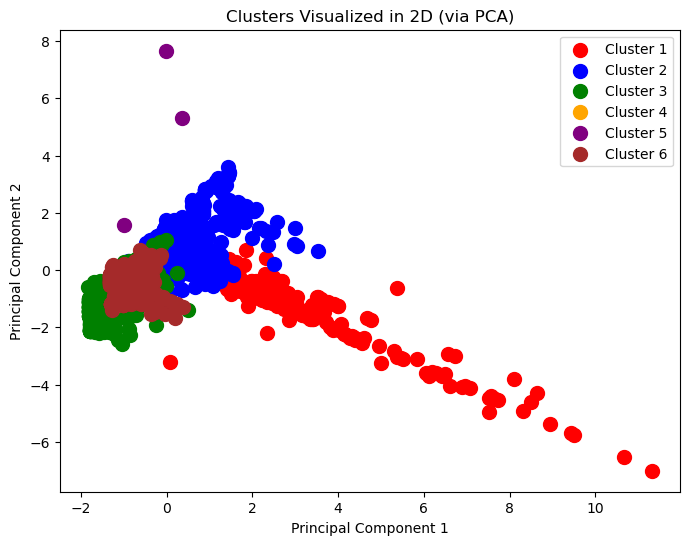

In [25]:
#Now, we analyze the clusters with a scatter chart.
colours = ['Red', 'Blue', 'Green', 'Orange', 'Purple', 'Brown'] 

plt.figure(figsize=(8, 6))
plt.title('Clusters Visualized in 2D (via PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Loop through each cluster and plot the points with their assigned color
for i in range(k):
    # Select data points belonging to cluster 'i'
    plt.scatter(
        X_reduced[y_hc == i, 0],  # PC1 values
        X_reduced[y_hc == i, 1],  # PC2 values
        s=100, 
        c=colours[i], 
        label=f'Cluster {i+1}')

plt.legend()
plt.show()




